## Intercept-only Linear Regression: Visualising Gradient Descent

We study the simplest possible regression model, where the model always predicts a single constant value $w_0$ for every input.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)  # Initialize a default random number generator with a seed for reproducibility

### Create a toy dataset

We start by creating a small synthetic dataset of target values $y^{(i)}$. Since the model has no input features, these targets are all we need.

In [2]:
N = 30  # Define the number of data points
y = rng.normal(loc=3, scale=1.2, size=N)  # Generate N random numbers from a normal distribution with mean 3.0 and standard deviation 1.2

print(f"N = {N}")
print(f"Sample mean of y: {np.mean(y):.3f}")

N = 30
Sample mean of y: 3.020


### Define the MSE objective

The mean squared error (MSE) measures how far the constant prediction $w_0$ is from the observed targets on average. We will treat the MSE as a function of $w_0$ and visualise it.

In [3]:
def J(w0):
    return float(np.mean((w0 - y) ** 2))

### Plot the objective function

Here we plot the objective $\mathcal{J}(w_0)$ over a range of values. This curve is the landscape that gradient descent will move along.

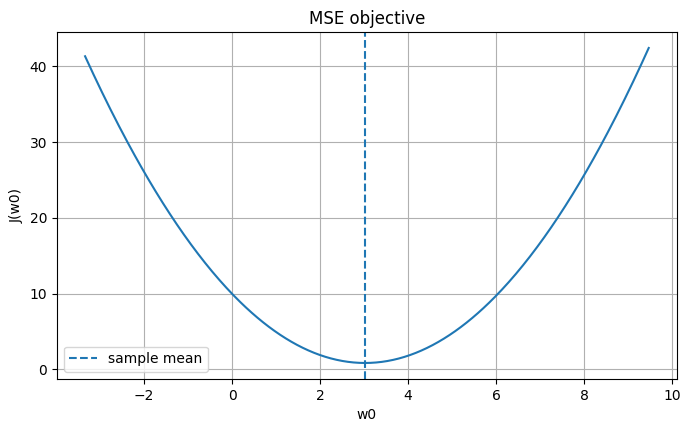

In [4]:
# Create a grid of w0 values
w0_grid = np.linspace(np.min(y) - 4, np.max(y) + 5, 400)

# Calculate the MSE objective J for each w0 value in the grid
J_grid = [J(w0) for w0 in w0_grid]

# Plot the J curve
plt.figure(figsize=(8, 4.5))
plt.plot(w0_grid, J_grid)
plt.axvline(np.mean(y), linestyle="--", label="sample mean")
plt.xlabel("w0")
plt.ylabel("J(w0)")
plt.title("MSE objective")
plt.legend()
plt.grid(True)
plt.show()

### Compute the gradient

The function `grad_J` computes the **gradient** of the MSE objective $\mathcal{J}(w_0)$ with respect to $w_0$. The gradient describes the slope of the objective curve at the current value of $w_0$: it indicates both the direction and the rate at which the objective changes.

Concretely, it tells us how $\mathcal{J}(w_0)$ would change if we increased $ w_0$ by a small amount. A positive gradient means the objective increases as $w_0$ increases, so $w_0$ should be decreased; a negative gradient means the objective decreases as $w_0$ increases, so $w_0$ should be increased.

In [5]:
def grad_J(w0):
    return (2.0 / N) * np.sum(w0 - y)

# Initialise the model weight (expect negative gradient)
w0 = 0.0
print("Initial w0:", w0)
print("Gradient:", grad_J(w0))

Initial w0: 0.0
Gradient: -6.040353889938531


### One gradient descent update

Using the gradient, we update $w_0$ once. This is a single step of gradient descent.

In [6]:
eta = 0.2
w0_new = w0 - eta * grad_J(w0)

print("Updated w0:", w0_new)
print("J(w0) before:", J(w0))
print("J(w0) after:", J(w0_new))

Updated w0: 1.2080707779877065
J(w0) before: 9.961316830430318
J(w0) after: 4.123576811919032


### Run gradient descent for multiple steps

We now repeat the gradient descent update several times to see how $w_0$ moves towards the minimum of the objective.

In [7]:
steps = 15
w0 = 0.0
w_hist = [w0]
J_hist = [J(w0)]

for _ in range(steps):
    w0 = w0 - eta * grad_J(w0)
    w_hist.append(w0)
    J_hist.append(J(w0))

print("Final w0:", w0)
print("Sample mean:", np.mean(y))

Final w0: 3.018756903118978
Sample mean: 3.0201769449692657


### Visualise the trajectory

Finally, we plot all gradient descent iterates on top of the objective curve to see how the algorithm converges.

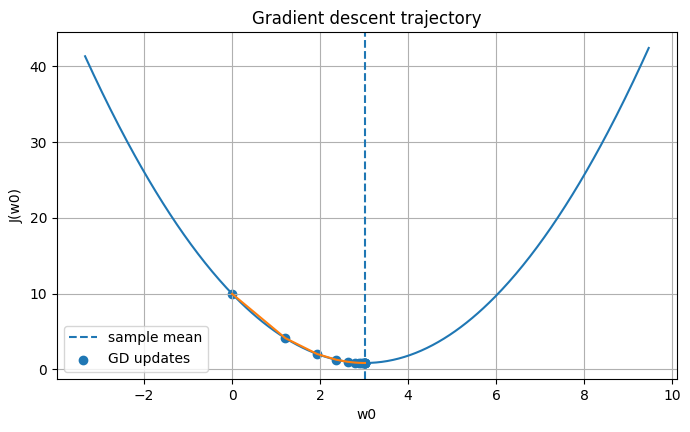

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(w0_grid, J_grid)
plt.axvline(np.mean(y), linestyle="--", label="sample mean")
plt.scatter(w_hist, J_hist, label="GD updates")
plt.plot(w_hist, J_hist)
plt.xlabel("w0")
plt.ylabel("J(w0)")
plt.title("Gradient descent trajectory")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
#@title Interactive visualisation

# Interactive widgets
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False


def make_plot(w0_init=0.0, eta=0.2, steps=15):

    # Grid for objective curve
    ws = np.linspace(np.min(y) - 4, np.max(y) + 4, 400)
    Js = np.array([J(w) for w in ws])

    # Run gradient descent
    w_hist = [float(w0_init)]
    J_hist = [J(w_hist[-1])]
    for _ in range(int(steps)):
        w_new = w_hist[-1] - float(eta) * grad_J(w_hist[-1])
        w_hist.append(float(w_new))
        J_hist.append(J(w_hist[-1]))
    w_hist = np.array(w_hist)
    J_hist = np.array(J_hist)

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(ws, Js)
    plt.axvline(np.mean(y), linestyle="--", linewidth=1.5, label=f"target mean = {np.mean(y):.3f}")

    # GD path (w0 on x-axis, J on y-axis)
    plt.scatter(w_hist, J_hist, s=35, label="gradient descent iterates")
    plt.plot(w_hist, J_hist, linewidth=1)

    # Annotate first/last
    plt.annotate("start", (w_hist[0], J_hist[0]), textcoords="offset points", xytext=(8, 8))
    plt.annotate("end", (w_hist[-1], J_hist[-1]), textcoords="offset points", xytext=(8, -14))

    plt.title("Intercept-only linear regression: MSE objective and gradient descent updates")
    plt.xlabel(r"$w_0$")
    plt.ylabel(r"$\mathcal{J}(w_0)$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Also show the history values
    print(f"Sample mean of targets: {np.mean(y):.6f}")
    print(f"Final w0 after {steps} steps: {w_hist[-1]:.6f}")
    print(f"Final objective: {J_hist[-1]:.6f}")

if _HAS_WIDGETS:
    w0_init_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=10.0, step=0.1, description="w0 init")
    eta_slider = widgets.FloatLogSlider(value=0.2, base=10, min=-3, max=0, step=0.05, description="eta")
    steps_slider = widgets.IntSlider(value=15, min=1, max=60, step=1, description="steps")

    ui = widgets.VBox([w0_init_slider, eta_slider, steps_slider])
    out = widgets.interactive_output(make_plot, {
        "w0_init": w0_init_slider,
        "eta": eta_slider,
        "steps": steps_slider
    })

    display(ui, out)
else:
    # Fallback (non-interactive)
    make_plot(w0_init=0.0, eta=0.2, steps=15)


Output()

## 2D parameter space


### Create a toy dataset


In [10]:
N = 200 # Number of data points
x = rng.uniform(0, 10, size=N) # Generate N random x values between 0 and 10

w0_true = 1.0 # True intercept
w1_true = 0.5 # True slope

y_true = w0_true + w1_true * x # Calculate true y values

noise = rng.normal(loc=0, scale=1.0, size=N) # Generate N random noise values
y = y_true + noise # Add noise to get the final synthetic y

print(f"Generated {N} data points.")
print(f"True intercept (w0_true): {w0_true}")
print(f"True slope (w1_true): {w1_true}")
print(f"First 5 x values: {x[:5]}")
print(f"First 5 y values: {y[:5]}")

Generated 200 data points.
True intercept (w0_true): 1.0
True slope (w1_true): 0.5
First 5 x values: [7.44762156 9.67509732 3.25825358 3.70459706 4.69555811]
First 5 y values: [4.81430056 6.06577699 5.14660083 4.72914314 2.49453571]


### Define MSE objective for two parameters

In [11]:
def J(w0, w1):
    y_predicted = w0 + w1 * x
    return float(np.mean((y_predicted - y) ** 2))


### Define gradient functions for two parameters

In [12]:
def grad_J_w0(w0, w1):
    return (2.0 / N) * np.sum(w0 + w1 * x - y)

def grad_J_w1(w0, w1):
    return (2.0 / N) * np.sum((w0 + w1 * x - y) * x)


### Run Gradient Descent in 2D



In [13]:
w0 = 0.0  # Initial intercept
w1 = 0.0  # Initial slope
eta = 0.02  # Learning rate
steps = 300  # Number of gradient descent steps

w0_hist = [w0]  # History of w0 values
w1_hist = [w1]  # History of w1 values
J_hist = [J(w0, w1)]  # History of J values

for i in range(steps):
    grad_w0 = grad_J_w0(w0, w1)
    grad_w1 = grad_J_w1(w0, w1)

    w0 = w0 - eta * grad_w0
    w1 = w1 - eta * grad_w1

    w0_hist.append(w0)
    w1_hist.append(w1)
    J_hist.append(J(w0, w1))

print(f"Final w0: {w0:.3f}")
print(f"Final w1: {w1:.3f}")
print(f"Final J(w0, w1): {J(w0, w1):.3f}")

Final w0: 0.921
Final w1: 0.516
Final J(w0, w1): 1.068


Analytical minimum (w0_ols): 0.964
Analytical minimum (w1_ols): 0.510


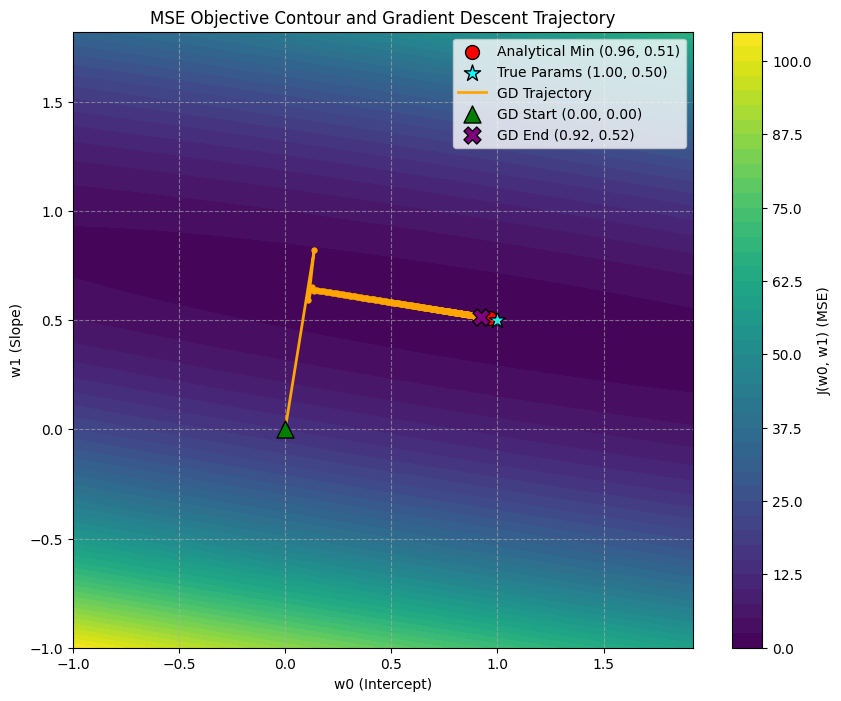

In [16]:
#@title Visualize 2D objective and trajectory

# 1. Define ranges for w0 and w1 to create a grid for the contour plot.
w0_vals = np.linspace(min(w0_hist) - 1, max(w0_hist) + 1, 100)
w1_vals = np.linspace(min(w1_hist) - 1, max(w1_hist) + 1, 100)

# 2. Create 2D grids W0 and W1 from w0_vals and w1_vals using np.meshgrid.
W0, W1 = np.meshgrid(w0_vals, w1_vals)

# 3. Calculate the MSE J_values for each point in the (W0, W1) grid.
J_values = np.zeros_like(W0, dtype=float)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        J_values[i, j] = J(W0[i, j], W1[i, j])

# 4. Calculate the analytical minimum w0_ols and w1_ols using OLS formulas.
x_mean = np.mean(x)
y_mean = np.mean(y)
w1_ols = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
w0_ols = y_mean - w1_ols * x_mean

print(f"Analytical minimum (w0_ols): {w0_ols:.3f}")
print(f"Analytical minimum (w1_ols): {w1_ols:.3f}")

# 5. Create a new figure and an axes object using plt.figure() and fig.add_subplot().
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

# 6. Plot the contour lines of the J_values.
c = ax.contourf(W0, W1, J_values, levels=50, cmap='viridis')

# 7. Add a color bar to the contour plot.
fig.colorbar(c, ax=ax, label='J(w0, w1) (MSE)')

# 8. Plot the analytical minimum point (w0_ols, w1_ols).
ax.scatter(w0_ols, w1_ols, color='red', marker='o', s=100, label=f'Analytical Min ({w0_ols:.2f}, {w1_ols:.2f})', edgecolor='black')

# 9. Plot the true parameters (w0_true, w1_true).
ax.scatter(w0_true, w1_true, color='cyan', marker='*', s=150, label=f'True Params ({w0_true:.2f}, {w1_true:.2f})', edgecolor='black')

# 10. Plot the gradient descent trajectory.
ax.plot(w0_hist, w1_hist, color='orange', linestyle='-', linewidth=2, label='GD Trajectory')
ax.scatter(w0_hist, w1_hist, color='orange', marker='.', s=50, zorder=5)

# 11. Mark the starting point of the GD trajectory.
ax.scatter(w0_hist[0], w1_hist[0], color='green', marker='^', s=150, label=f'GD Start ({w0_hist[0]:.2f}, {w1_hist[0]:.2f})', edgecolor='black', zorder=10)

# 12. Mark the ending point of the GD trajectory.
ax.scatter(w0_hist[-1], w1_hist[-1], color='purple', marker='X', s=150, label=f'GD End ({w0_hist[-1]:.2f}, {w1_hist[-1]:.2f})', edgecolor='black', zorder=10)

# 13. Add labels for the x-axis (w0), y-axis (w1), and a title to the plot.
ax.set_xlabel('w0 (Intercept)')
ax.set_ylabel('w1 (Slope)')
ax.set_title('MSE Objective Contour and Gradient Descent Trajectory')

# 14. Add a legend.
ax.legend()

# 15. Display the plot.
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [17]:
#@title Interactive visualisation

# Interactive widgets
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAS_WIDGETS_2D = True
except Exception:
    _HAS_WIDGETS_2D = False

def make_plot_2d(w0_init=0.0, w1_init=0.0, eta=0.01, steps=100):
    # Re-run gradient descent with interactive parameters
    w0_current = float(w0_init)
    w1_current = float(w1_init)
    eta_current = float(eta)
    steps_current = int(steps)

    w0_hist = [w0_current]
    w1_hist = [w1_current]
    J_hist = [J(w0_current, w1_current)]

    for _ in range(steps_current):
        grad_w0 = grad_J_w0(w0_current, w1_current)
        grad_w1 = grad_J_w1(w0_current, w1_current)

        w0_current = w0_current - eta_current * grad_w0
        w1_current = w1_current - eta_current * grad_w1

        w0_hist.append(w0_current)
        w1_hist.append(w1_current)
        J_hist.append(J(w0_current, w1_current))

    # Calculate the analytical minimum w0_ols and w1_ols using OLS formulas.
    # These are static for the given dataset, so we can use the pre-calculated ones or re-calculate for clarity.
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    w1_ols = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
    w0_ols = y_mean - w1_ols * x_mean

    # 1. Define ranges for w0 and w1 to create a grid for the contour plot.
    # Adjust ranges dynamically based on the GD trajectory to ensure visibility
    w0_min_plot = min(min(w0_hist), w0_true, w0_ols) - 1
    w0_max_plot = max(max(w0_hist), w0_true, w0_ols) + 1
    w1_min_plot = min(min(w1_hist), w1_true, w1_ols) - 1
    w1_max_plot = max(max(w1_hist), w1_true, w1_ols) + 1

    w0_vals = np.linspace(w0_min_plot, w0_max_plot, 100)
    w1_vals = np.linspace(w1_min_plot, w1_max_plot, 100)

    # 2. Create 2D grids W0 and W1 from w0_vals and w1_vals using np.meshgrid.
    W0, W1 = np.meshgrid(w0_vals, w1_vals)

    # 3. Calculate the MSE J_values for each point in the (W0, W1) grid.
    J_values = np.array([J(w0_val, w1_val) for w0_val, w1_val in zip(W0.ravel(), W1.ravel())]).reshape(W0.shape)

    # 5. Create a new figure and an axes object using plt.figure() and fig.add_subplot().
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)

    # 6. Plot the contour lines of the J_values.
    c = ax.contourf(W0, W1, J_values, levels=50, cmap='viridis')

    # 7. Add a color bar to the contour plot.
    fig.colorbar(c, ax=ax, label=r'$\mathcal{J}(w_0, w_1)$ (MSE)')

    # 8. Plot the analytical minimum point (w0_ols, w1_ols).
    ax.scatter(w0_ols, w1_ols, color='red', marker='o', s=100, label=f'Analytical Min ({w0_ols:.2f}, {w1_ols:.2f})', edgecolor='black', zorder=10)

    # 9. Plot the true parameters (w0_true, w1_true).
    ax.scatter(w0_true, w1_true, color='cyan', marker='*', s=150, label=f'True Params ({w0_true:.2f}, {w1_true:.2f})', edgecolor='black', zorder=10)

    # 10. Plot the gradient descent trajectory.
    ax.plot(w0_hist, w1_hist, color='orange', linestyle='-', linewidth=2, label='GD Trajectory')
    ax.scatter(w0_hist, w1_hist, color='orange', marker='.', s=50, zorder=5)

    # 11. Mark the starting point of the GD trajectory.
    ax.scatter(w0_hist[0], w1_hist[0], color='green', marker='^', s=150, label=f'GD Start ({w0_hist[0]:.2f}, {w1_hist[0]:.2f})', edgecolor='black', zorder=10)

    # 12. Mark the ending point of the GD trajectory.
    ax.scatter(w0_hist[-1], w1_hist[-1], color='purple', marker='X', s=150, label=f'GD End ({w0_hist[-1]:.2f}, {w1_hist[-1]:.2f})', edgecolor='black', zorder=10)

    # 13. Add labels for the x-axis (w0), y-axis (w1), and a title to the plot.
    ax.set_xlabel(r'$w_0$ (Intercept)')
    ax.set_ylabel(r'$w_1$ (Slope)')
    ax.set_title('MSE Objective Contour and Gradient Descent Trajectory')

    # 14. Add a legend.
    ax.legend()

    # 15. Display the plot.
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    print(f"True parameters: w0={w0_true:.3f}, w1={w1_true:.3f}")
    print(f"Analytical minimum (OLS): w0={w0_ols:.3f}, w1={w1_ols:.3f}")
    print(f"Final GD parameters: w0={w0_hist[-1]:.3f}, w1={w1_hist[-1]:.3f}")
    print(f"Final objective value: {J_hist[-1]:.3f}")

if _HAS_WIDGETS_2D:
    w0_init_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description="w0 init")
    w1_init_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description="w1 init")
    eta_slider = widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=0, step=0.05, description="eta")
    steps_slider = widgets.IntSlider(value=100, min=1, max=1000, step=10, description="steps")

    ui = widgets.VBox([w0_init_slider, w1_init_slider, eta_slider, steps_slider])
    out = widgets.interactive_output(make_plot_2d, {
        "w0_init": w0_init_slider,
        "w1_init": w1_init_slider,
        "eta": eta_slider,
        "steps": steps_slider
    })

    display(ui, out)
else:
    # Fallback (non-interactive)
    print("ipywidgets not available. Displaying a static plot.")
    make_plot_2d(w0_init=0.0, w1_init=0.0, eta=0.01, steps=100)

Output()